In [1]:
from MLtools import ImageData, SC_Model
from torch.utils.data import DataLoader, random_split
import torch
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt
import imageio.v2 as imageio
from torchvision.transforms import Resize

In [2]:
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

model = torch.load("SC_model1.pth", weights_only=False).to(device)

In [3]:
name = "test.jpg"
transform = Resize((640,640))

image = imageio.imread(name)
image = image.swapaxes(0,2).swapaxes(1,2)/255.0
image = torch.from_numpy(image)
image = transform(image)
image = torch.unsqueeze(image, 0)

print(image.shape)

torch.Size([1, 3, 640, 640])


In [4]:
with torch.no_grad():
    heat_map = model(image.float().to(device)).view((640,640))

heat_map.shape

torch.Size([640, 640])

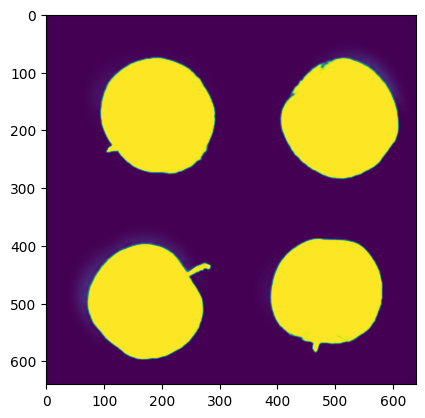

In [5]:
heat_map = heat_map.to('cpu').numpy()
plt.imshow(heat_map)

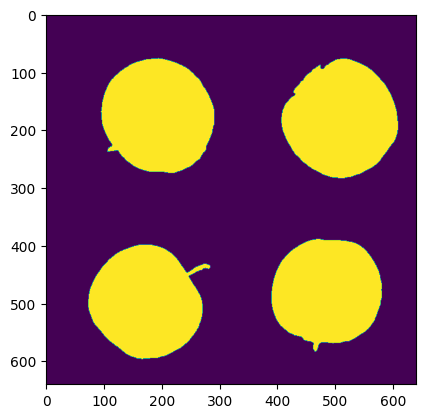

In [6]:
ind = np.where(heat_map > 0.9)
pic = np.zeros((640,640))
pic[ind] = 1
plt.imshow(pic)

In [7]:
print(f'N pixels: {len(ind[0])}')

N pixels: 118823


In [8]:
len(ind[0])/640**2

0.29009521484375

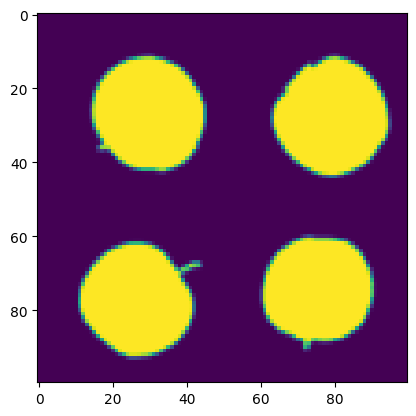

In [9]:
tr = Resize((100, 100))

pic = torch.from_numpy(pic)
pic = torch.unsqueeze(pic, 0)
pic = tr(pic).view((100,100)).numpy()

ind = np.where(pic > 0.9)

plt.imshow(pic)

In [10]:
X = []
for i in range(len(ind[0])):
    X.append([ind[0][i], ind[1][i]])

In [17]:
from sklearn.cluster import MeanShift

clustering = MeanShift(bandwidth=20).fit(X)

In [18]:
len(clustering.cluster_centers_)

4

In [19]:
clustering.cluster_centers_

array([[28.01564723, 79.15078236],
       [27.08100147, 29.81148748],
       [77.45864662, 26.39398496],
       [74.50871632, 75.42630745]])